In [3]:
!pip install tqdm

  Using cached tqdm-4.67.0-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.0-py3-none-any.whl (78 kB)



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\nabil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import os
import pandas as pd
import numpy as np
# import tqdm
from sklearn.preprocessing import StandardScaler,  LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import MeanSquaredError
from tqdm import tqdm
import keras

# Fonction pour traiter un fichier parquet
def  process_file(file_path):
    df = pd.read_parquet(file_path)  # Charger le fichier Parquet
    if 'step' in df.columns:
        df = df.drop('step', axis=1)  # Supprimer la colonne 'step' si elle existe
    stats = df.describe().values.reshape(-1)  # Extraire les statistiques descriptives
    id_value = os.path.basename(os.path.dirname(file_path)).split('=')[1]  # Extraire l'ID
    return stats, id_value

# Fonction pour charger et traiter les séries temporelles d'un répertoire
def load_time_series(directory):
    ids = os.listdir(directory)  # Liste des répertoires (chaque ID est un sous-dossier)
    all_stats = []
    all_ids = []
    for id_dir in tqdm(ids):  # Progression dans les IDs
        file_path = os.path.join(directory, id_dir, 'part-0.parquet')  # Chemin du fichier
        if os.path.exists(file_path):  # Vérifier si le fichier existe
            stats, id_value = process_file(file_path)  # Extraire stats et ID
            all_stats.append(stats)
            all_ids.append(id_value)
    num_features = len(all_stats[0])  # Nombre de statistiques extraites
    columns = [f"TS_Feature_{i}" for i in range(num_features)]  # Noms des colonnes
    df = pd.DataFrame({'id': all_ids})  # Créer un DataFrame avec les IDs
    df[columns] = all_stats  # Ajouter les statistiques
    return df


In [ ]:
# Charger les séries temporelles (train et test)
series_train_df = load_time_series('../data/series_train.parquet')
series_test_df = load_time_series('../data/series_test.parquet')

100%|██████████| 2/2 [00:00<00:00,  5.54it/s]


In [42]:
# Charger les données tabulaires (train et test)
tabular_train_df = pd.read_csv('../data/train.csv')
tabular_test_df = pd.read_csv('../data/test.csv')

In [43]:
tabular_train_df.shape

(3960, 82)

In [44]:
tabular_test_df.shape

(20, 59)

In [45]:
# Fusionner les données tabulaires et temporelles
train_df = pd.merge(tabular_train_df, series_train_df, how='left', on='id')
test_df = pd.merge(tabular_test_df, series_test_df, how='left', on='id')

In [46]:
train_df.shape

(3960, 178)

In [47]:
test_df.shape

(20, 155)

In [48]:
from tensorflow.keras.utils import to_categorical

# Supprimer les lignes où 'sii' est manquant
train_df = train_df.dropna(subset=['sii'])


y_train = train_df['sii'] if 'sii' in train_df.columns else None  # Utilisation de 'sii' comme cible
# Encodage des labels pour classification multi-classes (one-hot encoding)
y_train = to_categorical(y_train, num_classes=4)  # Convertir les labels en one-hot



# Garder uniquement les colonnes communes entre train et test
common_columns = train_df.columns.intersection(test_df.columns)
train_df = train_df[common_columns]
test_df = test_df[common_columns]



# Identifier les colonnes numériques
numeric_cols = train_df.select_dtypes(include=[np.number]).columns

# Remplir les valeurs manquantes uniquement pour les colonnes numériques
train_df[numeric_cols] = train_df[numeric_cols].fillna(train_df[numeric_cols].mean())
test_df[numeric_cols] = test_df[numeric_cols].fillna(test_df[numeric_cols].mean())

In [11]:
# Gérer les colonnes non numériques (catégoriques)
for col in train_df.select_dtypes(include=['object']).columns:
    if col =='id':
        continue
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

# Séparer les caractéristiques et la cible dans le dataset d'entraînement
X_train = train_df.drop(columns=['id','sii'], errors='ignore')  # Supprimer 'id' et 'sii'


# # Préparer les données de test (en supposant qu'il n'y a pas de colonne cible 'sii')
X_test = test_df.drop(columns=['id'], errors='ignore')  # Supprimer 'id'

# # Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Ajuster et transformer les données d'entraînement
X_test_scaled = scaler.transform(X_test)       # Transformer les données de test avec le même scaler

In [12]:
X_train_scaled.shape

(2736, 154)

In [8]:
# Diviser les données en 80% train et 20% test
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

# SGD

Epoch 1/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - categorical_accuracy: 0.2821 - loss: 1.4403 - val_categorical_accuracy: 0.3358 - val_loss: 1.3859
Epoch 2/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.3486 - loss: 1.3674 - val_categorical_accuracy: 0.4033 - val_loss: 1.3189
Epoch 3/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.3984 - loss: 1.3073 - val_categorical_accuracy: 0.4507 - val_loss: 1.2632
Epoch 4/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - categorical_accuracy: 0.4349 - loss: 1.2531 - val_categorical_accuracy: 0.4945 - val_loss: 1.2170
Epoch 5/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.4950 - loss: 1.1974 - val_categorical_accuracy: 0.5055 - val_loss: 1.1781
Epoch 6/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5227 - loss: 1.1829 - val_categorical_accuracy: 0.5146 - val_loss: 1.1451
Epoch 7/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5267 - loss: 1.1372 - va

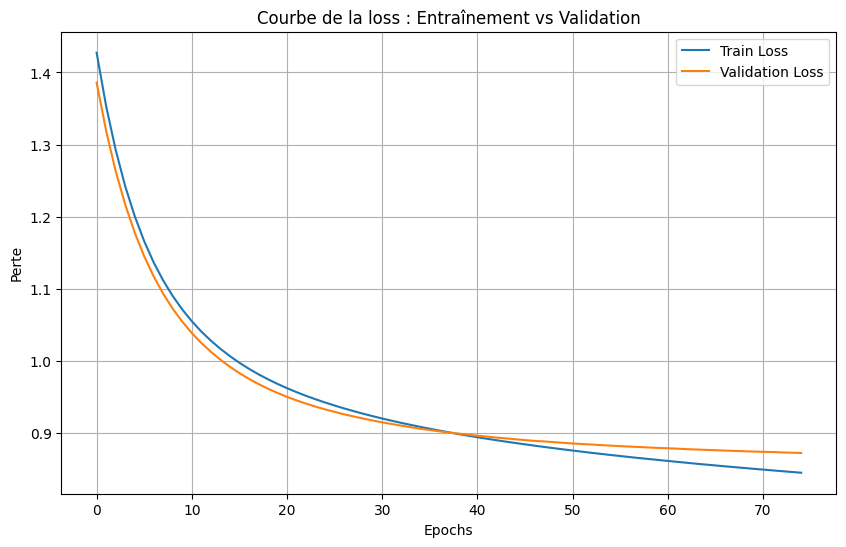

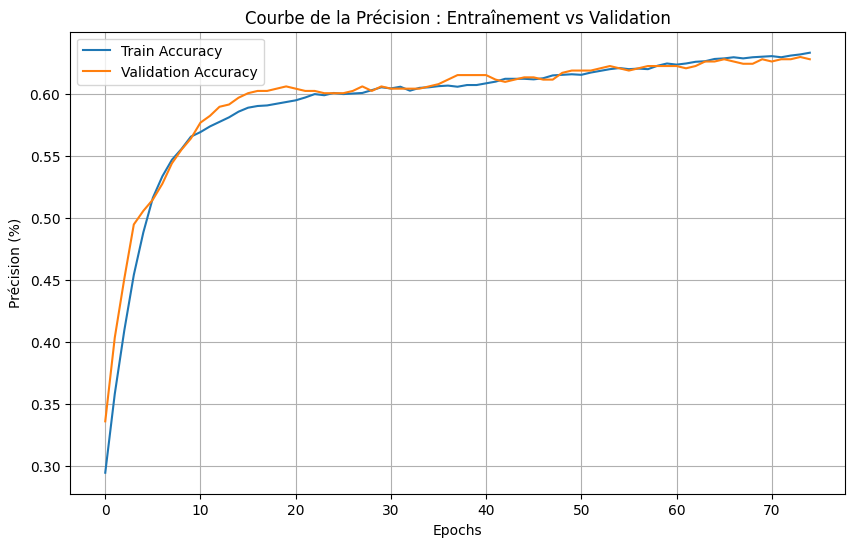

Précision finale sur le jeu de test : 62.77%


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import CategoricalAccuracy



# Construire le modèle
model = Sequential([
    Dense(128, activation='tanh', input_shape=(X_train_split.shape[1],)),  # Couche d'entrée
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(4, activation='softmax')  # Couche de sortie pour la classification multiclasses
])

# Compiler le modèle avec précision catégorielle
model.compile(
    optimizer=SGD(learning_rate=0.001), 
    loss='categorical_crossentropy', 
    metrics=[CategoricalAccuracy()]
)

# Entraîner le modèle sur le jeu d'entraînement
history_split = model.fit(
    X_train_split, 
    y_train_split, 
    validation_data=(X_test_split, y_test_split),  # Ajouter validation
    epochs=75, 
    batch_size=32, 
    verbose=1
)

# Extraire l'historique des pertes
train_loss = history_split.history['loss']
val_loss = history_split.history['val_loss']

# Extraire l'historique des précisions
train_accuracy = history_split.history['categorical_accuracy']
val_accuracy = history_split.history['val_categorical_accuracy']

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.title('Courbe de la loss : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Afficher le graphique des précisions
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Précision (%)')
plt.title('Courbe de la Précision : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Calculer l'accuracy finale sur le jeu de test
final_loss, final_accuracy = model.evaluate(X_test_split, y_test_split, verbose=0)
final_accuracy_percent = final_accuracy * 100

# Afficher l'accuracy finale sur le jeu de test
print(f"Précision finale sur le jeu de test : {final_accuracy_percent:.2f}%")

# Prédictions sur le jeu de test
# predictions = model.predict(X_test_scaled)

# Préparation des prédictions pour soumission sur Kaggle
# submission = pd.DataFrame({
#     'id': merged_test_df['id'],  # Réutilisez les IDs d'origine
#     'sii': predictions.flatten()
# })

# # Sauvegarde du fichier de soumission
# submission.to_csv('submission_SGD.csv', index=False)





In [8]:
model.save('model_MLP_SGD.h5')

In [9]:
X_test_split.shape

(548, 154)

In [15]:
y_test_split.shape

(548, 4)

In [10]:
X_train_split.shape

(2188, 154)

# RMSprop

Epoch 1/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - categorical_accuracy: 0.4701 - loss: 1.2347 - val_categorical_accuracy: 0.6223 - val_loss: 0.9287
Epoch 2/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.6211 - loss: 0.8704 - val_categorical_accuracy: 0.6223 - val_loss: 0.8738
Epoch 3/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.6471 - loss: 0.8159 - val_categorical_accuracy: 0.6296 - val_loss: 0.8853
Epoch 4/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - categorical_accuracy: 0.6787 - loss: 0.7660 - val_categorical_accuracy: 0.6095 - val_loss: 0.8957
Epoch 5/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.6855 - loss: 0.7407 - val_categorical_accuracy: 0.6387 - val_loss: 0.8858
Epoch 6/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.6983 - loss: 0.7124 - val_categorical_accuracy: 0.6241 - val_loss: 0.9094
Epoch 7/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.7312 - loss: 0.6687 - va

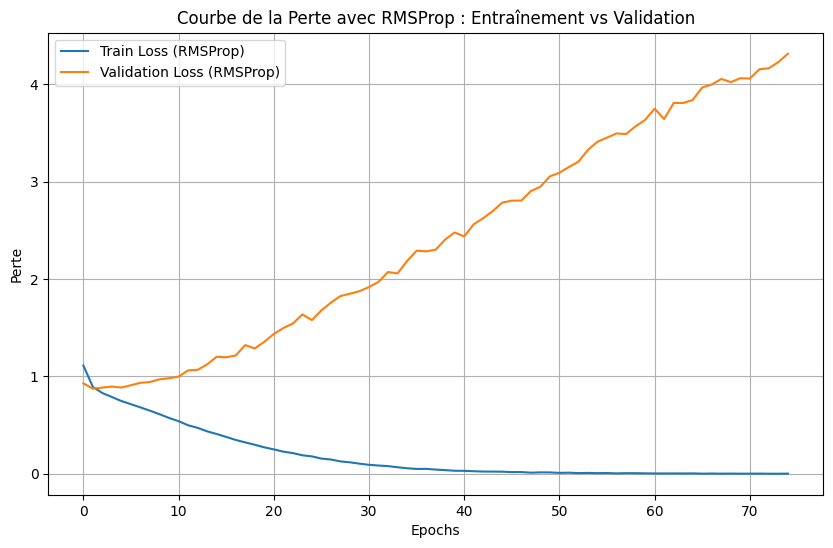

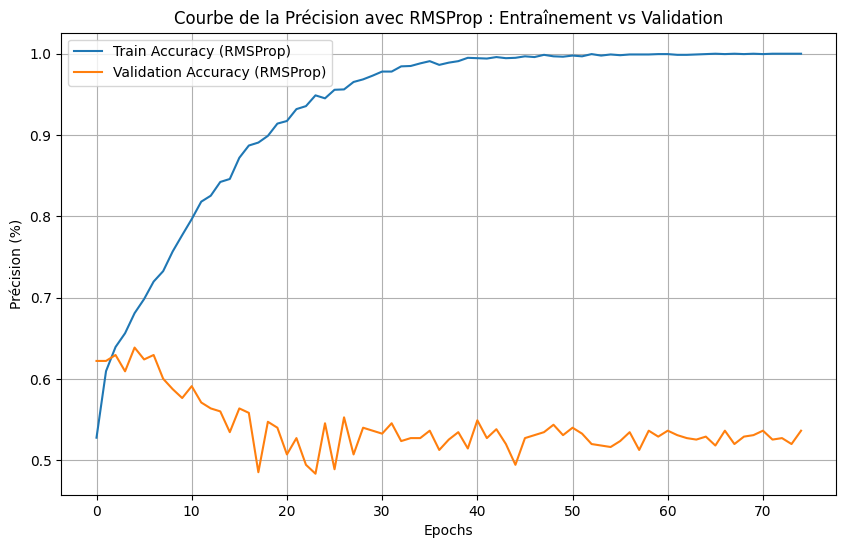

Précision finale sur le jeu de test avec RMSProp : 53.65%


In [19]:
from tensorflow.keras.optimizers import RMSprop

# Construire le modèle avec RMSProp
model_rmsprop = Sequential([
    Dense(128, activation='tanh', input_shape=(X_train_split.shape[1],)),  # Couche d'entrée
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(4, activation='softmax')  # Couche de sortie pour la classification multiclasses
])

# Compiler le modèle avec RMSProp
model_rmsprop.compile(
    optimizer=RMSprop(learning_rate=0.001),  # RMSProp avec un taux d'apprentissage de 0.001
    loss='categorical_crossentropy',
    metrics=[CategoricalAccuracy()]
)

# Entraîner le modèle sur le jeu d'entraînement avec RMSProp
history_rmsprop = model_rmsprop.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_test_split, y_test_split),  # Ajouter validation
    epochs=75, 
    batch_size=32, 
    verbose=1
)

# Extraire l'historique des pertes
train_loss_rmsprop = history_rmsprop.history['loss']
val_loss_rmsprop = history_rmsprop.history['val_loss']

# Extraire l'historique des précisions
train_accuracy_rmsprop = history_rmsprop.history['categorical_accuracy']
val_accuracy_rmsprop = history_rmsprop.history['val_categorical_accuracy']

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(train_loss_rmsprop, label='Train Loss (RMSProp)')
plt.plot(val_loss_rmsprop, label='Validation Loss (RMSProp)')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.title('Courbe de la Perte avec RMSProp : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Afficher le graphique des précisions
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy_rmsprop, label='Train Accuracy (RMSProp)')
plt.plot(val_accuracy_rmsprop, label='Validation Accuracy (RMSProp)')
plt.xlabel('Epochs')
plt.ylabel('Précision (%)')
plt.title('Courbe de la Précision avec RMSProp : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Calculer l'accuracy finale sur le jeu de test avec RMSProp
final_loss_rmsprop, final_accuracy_rmsprop = model_rmsprop.evaluate(X_test_split, y_test_split, verbose=0)
final_accuracy_rmsprop_percent = final_accuracy_rmsprop * 100

# Afficher l'accuracy finale sur le jeu de test
print(f"Précision finale sur le jeu de test avec RMSProp : {final_accuracy_rmsprop_percent:.2f}%")


# RMSprop avec Dropout

Epoch 1/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - categorical_accuracy: 1.0000 - loss: 5.9521e-06 - val_categorical_accuracy: 0.5274 - val_loss: 5.1763
Epoch 2/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 1.0000 - loss: 6.5225e-06 - val_categorical_accuracy: 0.5274 - val_loss: 5.1789
Epoch 3/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 1.0000 - loss: 5.9483e-06 - val_categorical_accuracy: 0.5274 - val_loss: 5.1801
Epoch 4/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 1.0000 - loss: 6.8543e-06 - val_categorical_accuracy: 0.5274 - val_loss: 5.1839
Epoch 5/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 1.0000 - loss: 6.4300e-06 - val_categorical_accuracy: 0.5274 - val_loss: 5.1861
Epoch 6/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 1.0000 - loss: 5.8991e-06 - val_categorical_accuracy: 0.5274 - val_loss: 5.1879
Epoch 7/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 1.

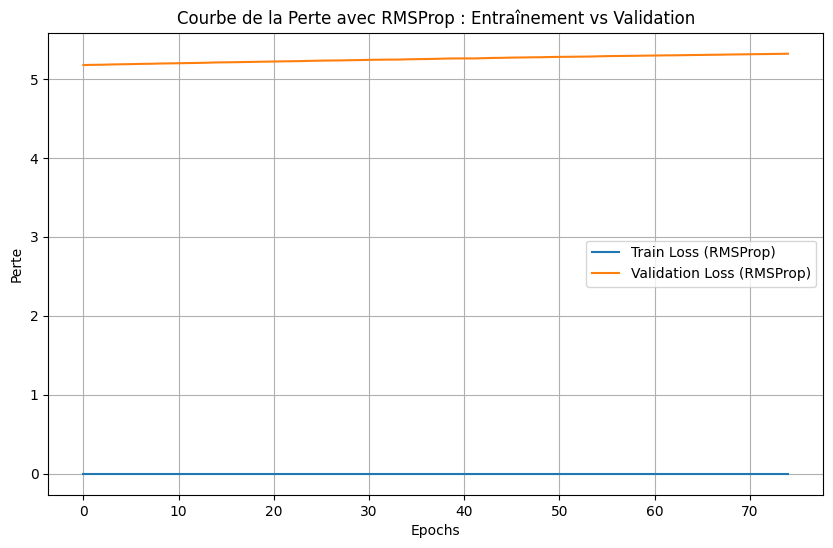

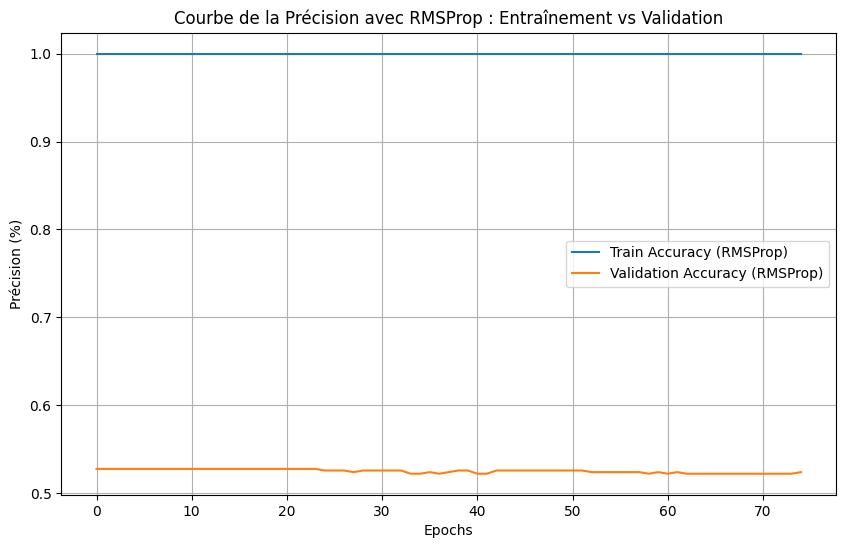

Précision finale sur le jeu de test avec RMSProp : 52.37%


In [ ]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout

model_rmsprop = Sequential([
    Dense(128, activation='tanh', input_shape=(X_train_split.shape[1],)),
    Dropout(0.03),
    Dense(64, activation='tanh'),
    Dropout(0.03),
    Dense(32, activation='tanh'),
    Dense(4, activation='softmax')
])
# Compiler le modèle avec RMSProp
model_rmsprop.compile(
    optimizer=RMSprop(learning_rate=0.001),  # RMSProp avec un taux d'apprentissage de 0.001
    loss='categorical_crossentropy',
    metrics=[CategoricalAccuracy()]
)

# Entraîner le modèle sur le jeu d'entraînement avec RMSProp
history_rmsprop = model_rmsprop.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_test_split, y_test_split),  # Ajouter validation
    epochs=75, 
    batch_size=32, 
    verbose=1
)

# Extraire l'historique des pertes
train_loss_rmsprop = history_rmsprop.history['loss']
val_loss_rmsprop = history_rmsprop.history['val_loss']

# Extraire l'historique des précisions
train_accuracy_rmsprop = history_rmsprop.history['categorical_accuracy']
val_accuracy_rmsprop = history_rmsprop.history['val_categorical_accuracy']

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(train_loss_rmsprop, label='Train Loss (RMSProp)')
plt.plot(val_loss_rmsprop, label='Validation Loss (RMSProp)')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.title('Courbe de la Perte avec RMSProp : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Afficher le graphique des précisions
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy_rmsprop, label='Train Accuracy (RMSProp)')
plt.plot(val_accuracy_rmsprop, label='Validation Accuracy (RMSProp)')
plt.xlabel('Epochs')
plt.ylabel('Précision (%)')
plt.title('Courbe de la Précision avec RMSProp : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Calculer l'accuracy finale sur le jeu de test avec RMSProp
final_loss_rmsprop, final_accuracy_rmsprop = model_rmsprop.evaluate(X_test_split, y_test_split, verbose=0)
final_accuracy_rmsprop_percent = final_accuracy_rmsprop * 100

# Afficher l'accuracy finale sur le jeu de test
print(f"Précision finale sur le jeu de test avec RMSProp : {final_accuracy_rmsprop_percent:.2f}%")


# RMSprop avec 1 couche cachée + diminution de nombre de neurones

Epoch 1/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - categorical_accuracy: 1.0000 - loss: 4.3031e-06 - val_categorical_accuracy: 0.5237 - val_loss: 5.3218
Epoch 2/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 1.0000 - loss: 3.9273e-06 - val_categorical_accuracy: 0.5237 - val_loss: 5.3226
Epoch 3/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - categorical_accuracy: 1.0000 - loss: 4.2299e-06 - val_categorical_accuracy: 0.5237 - val_loss: 5.3243
Epoch 4/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - categorical_accuracy: 1.0000 - loss: 3.9690e-06 - val_categorical_accuracy: 0.5237 - val_loss: 5.3259
Epoch 5/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 1.0000 - loss: 3.8686e-06 - val_categorical_accuracy: 0.5237 - val_loss: 5.3273
Epoch 6/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 1.0000 - loss: 4.5167e-06 - val_categorical_accuracy: 0.5237 - val_loss: 5.3290
Epoch 7/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 1.

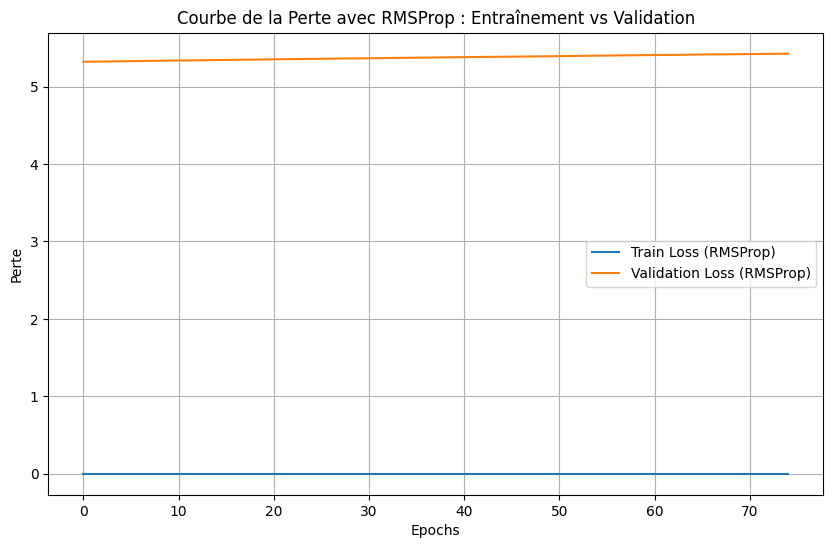

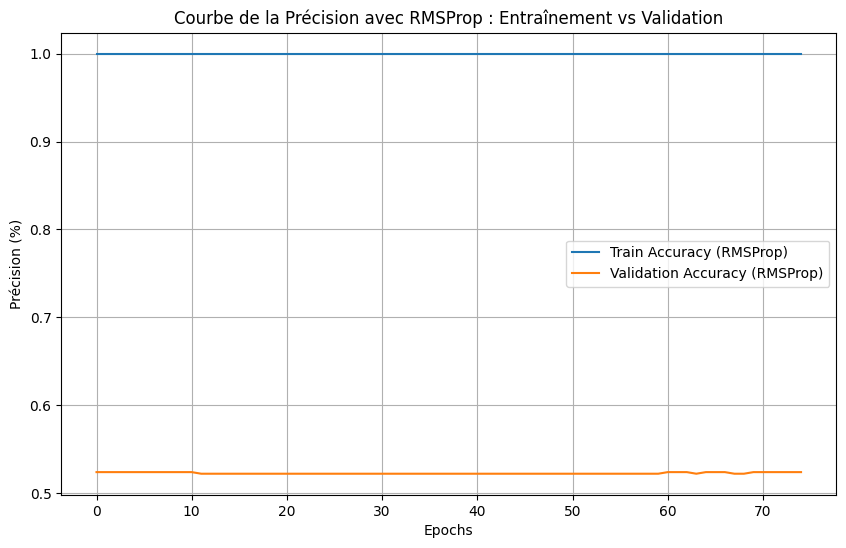

Précision finale sur le jeu de test avec RMSProp : 52.37%


In [ ]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout

model_rmsprop = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train_split.shape[1],)),
    # Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(4, activation='softmax')
])
# Compiler le modèle avec RMSProp
model_rmsprop.compile(
    optimizer=RMSprop(learning_rate=0.001),  # RMSProp avec un taux d'apprentissage de 0.001
    loss='categorical_crossentropy',
    metrics=[CategoricalAccuracy()]
)

# Entraîner le modèle sur le jeu d'entraînement avec RMSProp
history_rmsprop = model_rmsprop.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_test_split, y_test_split),  # Ajouter validation
    epochs=75, 
    batch_size=32, 
    verbose=1
)

# Extraire l'historique des pertes
train_loss_rmsprop = history_rmsprop.history['loss']
val_loss_rmsprop = history_rmsprop.history['val_loss']

# Extraire l'historique des précisions
train_accuracy_rmsprop = history_rmsprop.history['categorical_accuracy']
val_accuracy_rmsprop = history_rmsprop.history['val_categorical_accuracy']

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(train_loss_rmsprop, label='Train Loss (RMSProp)')
plt.plot(val_loss_rmsprop, label='Validation Loss (RMSProp)')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.title('Courbe de la Perte avec RMSProp : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Afficher le graphique des précisions
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy_rmsprop, label='Train Accuracy (RMSProp)')
plt.plot(val_accuracy_rmsprop, label='Validation Accuracy (RMSProp)')
plt.xlabel('Epochs')
plt.ylabel('Précision (%)')
plt.title('Courbe de la Précision avec RMSProp : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Calculer l'accuracy finale sur le jeu de test avec RMSProp
final_loss_rmsprop, final_accuracy_rmsprop = model_rmsprop.evaluate(X_test_split, y_test_split, verbose=0)
final_accuracy_rmsprop_percent = final_accuracy_rmsprop * 100

# Afficher l'accuracy finale sur le jeu de test
print(f"Précision finale sur le jeu de test avec RMSProp : {final_accuracy_rmsprop_percent:.2f}%")


# ADAM avec L2 et batch size 32

Epoch 1/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - categorical_accuracy: 0.4307 - loss: 3.4715 - val_categorical_accuracy: 0.5584 - val_loss: 1.3799
Epoch 2/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5522 - loss: 1.4446 - val_categorical_accuracy: 0.4088 - val_loss: 1.8220
Epoch 3/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5303 - loss: 1.8249 - val_categorical_accuracy: 0.5529 - val_loss: 1.8577
Epoch 4/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.5565 - loss: 1.6089 - val_categorical_accuracy: 0.5639 - val_loss: 1.4852
Epoch 5/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5667 - loss: 1.5928 - val_categorical_accuracy: 0.5456 - val_loss: 1.7733
Epoch 6/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5711 - loss: 1.7126 - val_categorical_accuracy: 0.5438 - val_loss: 1.5835
Epoch 7/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5352 - loss: 1.7363 - va

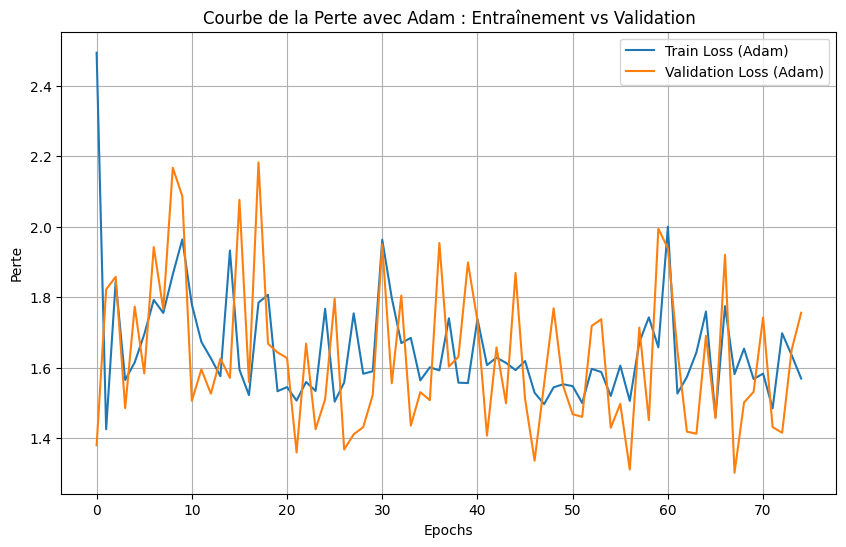

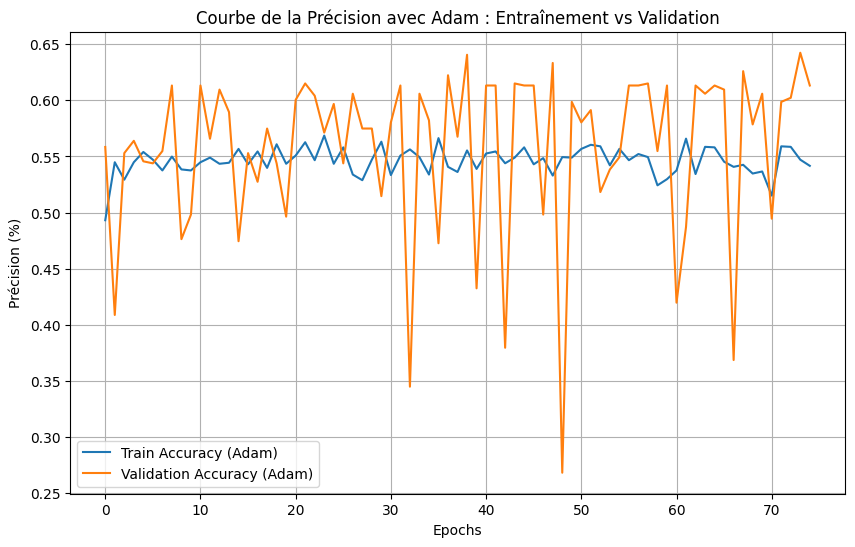

Précision finale sur le jeu de test avec Adam : 61.31%


In [31]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Construire un modèle avec Adam et régularisation
model_adam = Sequential([
    Dense(128, activation='tanh', input_shape=(X_train_split.shape[1],)),  # Couche d'entrée avec régularisation L2
    # Dropout(0.3),  # Désactivation aléatoire de 30% des neurones
    Dense(64, activation='tanh', kernel_regularizer=l2(0.01)),  # Couche cachée avec L2
    # Dropout(0.3),  # Dropout sur la couche cachée
    Dense(32, activation='tanh', kernel_regularizer=l2(0.01)),  # Couche cachée supplémentaire
    Dense(4, activation='softmax')  # Couche de sortie pour la classification multiclasses
])

# Compiler le modèle avec l'optimiseur Adam
model_adam.compile(
    optimizer=Adam(learning_rate=0.1),  # Adam avec un taux d'apprentissage par défaut
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# Entraîner le modèle avec Adam
history_adam = model_adam.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_test_split, y_test_split),  # Ajouter validation
    epochs=75, 
    batch_size=32, 
    verbose=1
)

# Extraire l'historique des pertes
train_loss_adam = history_adam.history['loss']
val_loss_adam = history_adam.history['val_loss']

# Extraire l'historique des précisions
train_accuracy_adam = history_adam.history['categorical_accuracy']
val_accuracy_adam = history_adam.history['val_categorical_accuracy']

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(train_loss_adam, label='Train Loss (Adam)')
plt.plot(val_loss_adam, label='Validation Loss (Adam)')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.title('Courbe de la Perte avec Adam : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Afficher le graphique des précisions
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy_adam, label='Train Accuracy (Adam)')
plt.plot(val_accuracy_adam, label='Validation Accuracy (Adam)')
plt.xlabel('Epochs')
plt.ylabel('Précision (%)')
plt.title('Courbe de la Précision avec Adam : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Calculer l'accuracy finale sur le jeu de test avec Adam
final_loss_adam, final_accuracy_adam = model_adam.evaluate(X_test_split, y_test_split, verbose=0)
final_accuracy_adam_percent = final_accuracy_adam * 100

# Afficher l'accuracy finale sur le jeu de test
print(f"Précision finale sur le jeu de test avec Adam : {final_accuracy_adam_percent:.2f}%")


# ADAM avec L2 / reduction Lr 

Epoch 1/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - categorical_accuracy: 0.4897 - loss: 2.0052 - val_categorical_accuracy: 0.6077 - val_loss: 1.0665
Epoch 2/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5923 - loss: 0.9805 - val_categorical_accuracy: 0.6259 - val_loss: 0.9609
Epoch 3/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.6142 - loss: 0.9273 - val_categorical_accuracy: 0.6241 - val_loss: 0.9072
Epoch 4/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.6185 - loss: 0.9005 - val_categorical_accuracy: 0.6332 - val_loss: 0.9191
Epoch 5/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.6234 - loss: 0.8886 - val_categorical_accuracy: 0.6241 - val_loss: 0.9666
Epoch 6/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.6031 - loss: 0.9159 - val_categorical_accuracy: 0.6241 - val_loss: 0.9299
Epoch 7/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.6488 - loss: 0.8708 - va

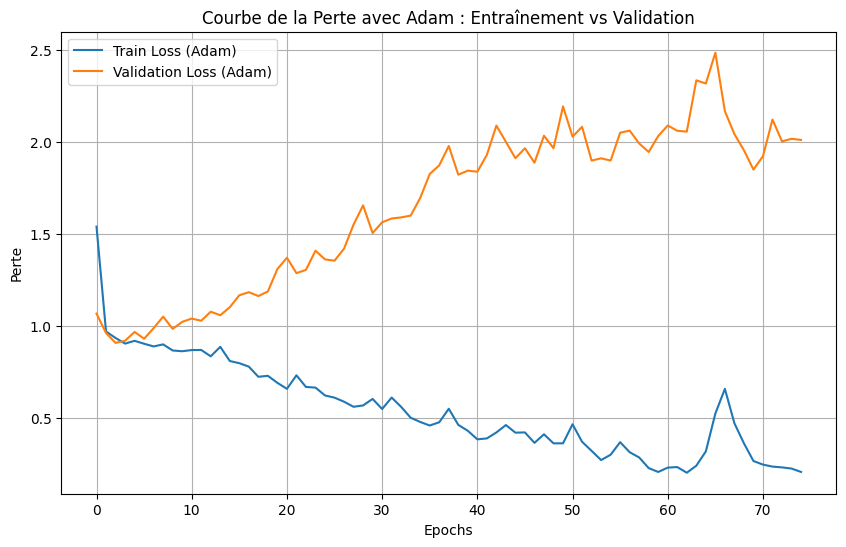

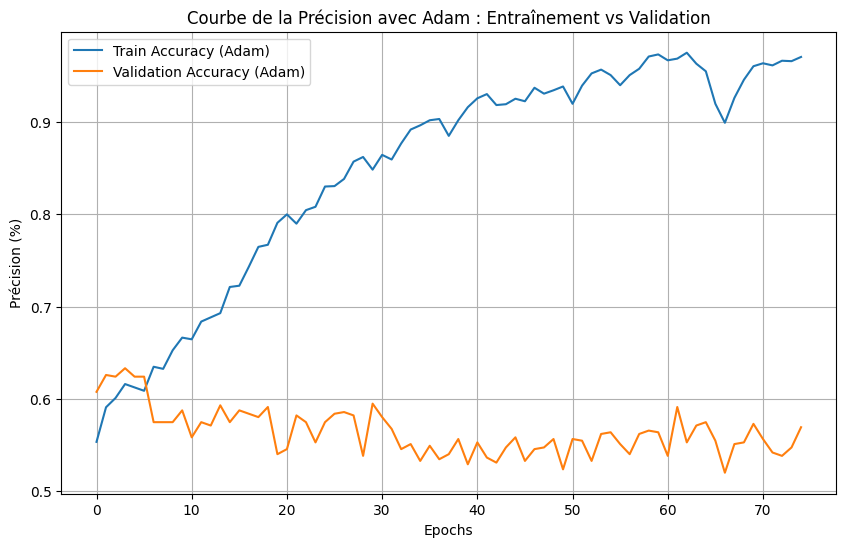

Précision finale sur le jeu de test avec Adam : 56.93%


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2


# Construire un modèle avec Adam et régularisation
model_adam = Sequential([
    Dense(128, activation='tanh', input_shape=(X_train_split.shape[1],)),  # Couche d'entrée avec régularisation L2
    # Dropout(0.3),  # Désactivation aléatoire de 30% des neurones
    Dense(64, activation='tanh', kernel_regularizer=l2(0.01)),  # Couche cachée avec L2
    # Dropout(0.3),  # Dropout sur la couche cachée
    Dense(32, activation='tanh', kernel_regularizer=l2(0.01)),  # Couche cachée supplémentaire
    Dense(4, activation='softmax')  # Couche de sortie pour la classification multiclasses
])

# Compiler le modèle avec l'optimiseur Adam
model_adam.compile(
    optimizer=Adam(learning_rate=0.01),  
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# Entraîner le modèle avec Adam
history_adam = model_adam.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_test_split, y_test_split),  # Ajouter validation
    epochs=75, 
    batch_size=32, 
    verbose=1
)

# Extraire l'historique des pertes
train_loss_adam = history_adam.history['loss']
val_loss_adam = history_adam.history['val_loss']

# Extraire l'historique des précisions
train_accuracy_adam = history_adam.history['categorical_accuracy']
val_accuracy_adam = history_adam.history['val_categorical_accuracy']

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(train_loss_adam, label='Train Loss (Adam)')
plt.plot(val_loss_adam, label='Validation Loss (Adam)')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.title('Courbe de la Perte avec Adam : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Afficher le graphique des précisions
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy_adam, label='Train Accuracy (Adam)')
plt.plot(val_accuracy_adam, label='Validation Accuracy (Adam)')
plt.xlabel('Epochs')
plt.ylabel('Précision (%)')
plt.title('Courbe de la Précision avec Adam : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Calculer l'accuracy finale sur le jeu de test avec Adam
final_loss_adam, final_accuracy_adam = model_adam.evaluate(X_test_split, y_test_split, verbose=0)
final_accuracy_adam_percent = final_accuracy_adam * 100

# Afficher l'accuracy finale sur le jeu de test
print(f"Précision finale sur le jeu de test avec Adam : {final_accuracy_adam_percent:.2f}%")


# Adam (avec correction du biais de l’EMA) batch size 32 

Epoch 1/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - categorical_accuracy: 0.4706 - loss: 1.3354 - val_categorical_accuracy: 0.5675 - val_loss: 1.0907
Epoch 2/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5199 - loss: 1.1003 - val_categorical_accuracy: 0.5748 - val_loss: 1.0649
Epoch 3/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5343 - loss: 1.0970 - val_categorical_accuracy: 0.5073 - val_loss: 1.1049
Epoch 4/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5254 - loss: 1.1024 - val_categorical_accuracy: 0.5456 - val_loss: 1.2168
Epoch 5/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5342 - loss: 1.0997 - val_categorical_accuracy: 0.5712 - val_loss: 1.0181
Epoch 6/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.5493 - loss: 1.0641 - val_categorical_accuracy: 0.5657 - val_loss: 1.0617
Epoch 7/75
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.5153 - loss: 1.0956 - va

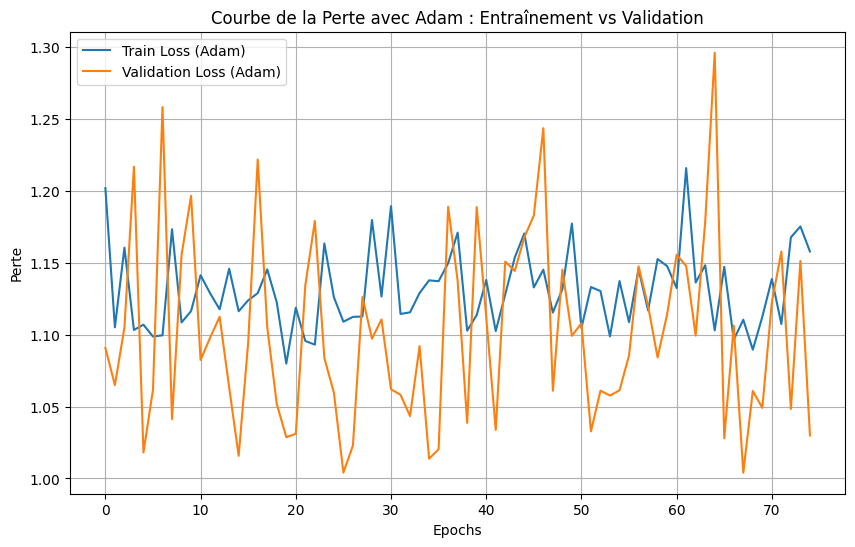

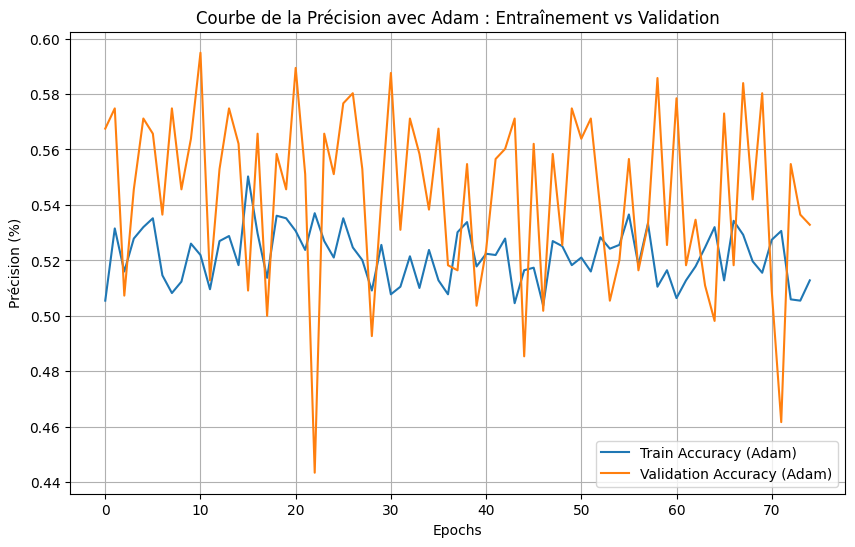

Précision finale sur le jeu de test avec Adam : 53.28%


In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)


# # Construire un modèle avec Adam et régularisation
# model_adam = Sequential([
#     Dense(128, activation='tanh', input_shape=(X_train_split.shape[1],)),  # Couche d'entrée avec régularisation L2
#     Dropout(0.3),  # Désactivation aléatoire de 30% des neurones
#     Dense(64, activation='tanh', kernel_regularizer=l2(0.01)),  # Couche cachée avec L2
#     Dropout(0.3),  # Dropout sur la couche cachée
#     Dense(32, activation='tanh', kernel_regularizer=l2(0.01)),  # Couche cachée supplémentaire
#     Dense(4, activation='softmax')  # Couche de sortie pour la classification multiclasses
# ])

model_adam = Sequential([
    Dense(128, activation='tanh', input_shape=(X_train_split.shape[1],)),  # Couche d'entrée avec régularisation L2
    Dropout(0.3),  # Désactivation aléatoire de 30% des neurones
    Dense(64, activation='tanh'),  # Couche cachée avec L2
    Dropout(0.3),  # Dropout sur la couche cachée
    Dense(32, activation='tanh'),  # Couche cachée supplémentaire
    Dense(4, activation='softmax')  # Couche de sortie pour la classification multiclasses
])

# Compiler le modèle avec l'optimiseur Adam
model_adam.compile(
    optimizer=Adam(learning_rate=0.1 , beta_1=0.9, beta_2=0.999, epsilon=1e-7),  # Adam avec un taux d'apprentissage par défaut
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# Entraîner le modèle avec Adam
history_adam = model_adam.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_test_split, y_test_split),  # Ajouter validation
    epochs=75, 
    batch_size=32, 
    verbose=1
)

# Extraire l'historique des pertes
train_loss_adam = history_adam.history['loss']
val_loss_adam = history_adam.history['val_loss']

# Extraire l'historique des précisions
train_accuracy_adam = history_adam.history['categorical_accuracy']
val_accuracy_adam = history_adam.history['val_categorical_accuracy']

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(train_loss_adam, label='Train Loss (Adam)')
plt.plot(val_loss_adam, label='Validation Loss (Adam)')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.title('Courbe de la Perte avec Adam : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Afficher le graphique des précisions
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy_adam, label='Train Accuracy (Adam)')
plt.plot(val_accuracy_adam, label='Validation Accuracy (Adam)')
plt.xlabel('Epochs')
plt.ylabel('Précision (%)')
plt.title('Courbe de la Précision avec Adam : Entraînement vs Validation')
plt.legend()
plt.grid(True)
plt.show()

# Calculer l'accuracy finale sur le jeu de test avec Adam
final_loss_adam, final_accuracy_adam = model_adam.evaluate(X_test_split, y_test_split, verbose=0)
final_accuracy_adam_percent = final_accuracy_adam * 100

# Afficher l'accuracy finale sur le jeu de test
print(f"Précision finale sur le jeu de test avec Adam : {final_accuracy_adam_percent:.2f}%")


In [4]:
import pandas as pd


series_train_df = pd.read_parquet("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/series_train.parquet/id=0a418b57/part-0.parquet")

In [5]:
series_train_df

,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,-0.075242,-0.256743,-0.973791,0.038081,-72.952141,0.0,5.0,4202.000000,51250000000000,2,4,-9.0
1,1,-0.265893,-0.270508,-0.765470,0.077430,-52.849220,0.0,0.5,4185.333496,51255000000000,2,4,-9.0
2,2,0.334517,-0.548602,-0.588596,0.039162,-44.118084,0.0,11.5,4185.500000,51260000000000,2,4,-9.0
3,3,0.000193,-0.021069,-0.999681,0.001450,-88.759613,0.0,0.0,4185.666504,51265000000000,2,4,-9.0
4,4,-0.000685,-0.020681,-0.997677,0.000491,-88.756958,0.0,8.5,4185.833496,51270000000000,2,4,-9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
213418,213418,0.391111,0.658119,-0.511350,0.060158,-35.455124,0.0,22.0,3817.430664,38745000000000,1,4,25.0
213419,213419,0.551039,0.078267,-0.787324,0.094029,-52.621586,0.0,22.0,3817.430664,38750000000000,1,4,25.0
213420,213420,0.667007,-0.126560,-0.751950,0.013104,-47.961002,0.0,22.0,3817.430664,39015000000000,1,4,25.0
213421,213421,0.666465,-0.125810,-0.749048,0.010495,-47.928806,0.0,22.0,3817.430664,39020000000000,1,4,25.0
